In [ ]:
#add libraries for tabular and vector data and for plotting
import pandas as pd #tab
import geopandas as gpd #vector
import matplotlib.pyplot as plt #basic plotting
import seaborn as sns #advanced plotting
#mount google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# read tab separated file
file = '/content/drive/My Drive/ESIIL2025MSU/Project Data/water_use'
#define the variable
water_use = pd.read_csv(file, sep='\t', comment='#', skiprows=11) # skip meta data rows
display(water_use.head())

,state_cd,state_name,year,"Total Population total population of area, in thousands","Public Supply population served by groundwater, in thousands","Public Supply population served by surface water, in thousands","Public Supply total population served, in thousands","Public Supply self-supplied groundwater withdrawals, fresh, in Mgal/d","Public Supply self-supplied groundwater withdrawals, saline, in Mgal/d","Public Supply total self-supplied withdrawals, groundwater, in Mgal/d",...,Hydroelectric Power total offstream surface-water withdrawals in Mgal/d,"Hydroelectric Power power generated by instream use, in gigawatt-hours","Hydroelectric Power power generated by offstream use, in gigawatt-hours","Hydroelectric Power total power generated, in gigawatt-hours",Hydroelectric Power number of instream facilities,Hydroelectric Power number of offstream facilities,Hydroelectric Power total number of facilities,"Wastewater Treatment returns by public wastewater facilities, in Mgal/d",Wastewater Treatment number of public wastewater facilities,"Wastewater Treatment reclaimed wastewater released by wastewater facilities, in Mgal/d"
0,8,Colorado,1985,3231.200,446.960,2562.510,3009.470,86.00,-,-,...,-,2399.21,-,-,-,-,-,336.28,255,-
1,8,Colorado,1990,3294.440,421.990,2624.100,3046.090,83.26,-,-,...,-,1318.49,-,-,30,-,-,361.39,223,-
2,8,Colorado,1995,3746.590,475.400,2918.600,3394.000,99.68,0.00,99.68,...,1386.17,1615.58,527.39,2142.97,23,9,32,421.96,393,-
3,8,Colorado,2000,4301.280,-,-,3746.320,53.69,-,-,...,-,-,-,-,-,-,-,-,-,-
4,8,Colorado,2005,4665.177,706.017,3683.036,4389.053,101.22,0.00,101.22,...,-,-,-,-,-,-,-,-,-,-


In [ ]:
# Create a list of columns with the substring 'consumptive'
cols_consumption = [col for col in water_use.columns if 'sumptive' in col]
print(cols_consumption)
#print length of cols_consumption
print(len(cols_consumption))

['Domestic consumptive use, fresh, in Mgal/d', 'Domestic consumptive use, saline, in Mgal/d', 'Domestic total consumptive use, in Mgal/d', 'Commercial consumptive use, fresh, in Mgal/d', 'Commercial consumptive use, saline, in Mgal/d', 'Commercial total consumptive use, in Mgal/d', 'Industrial consumptive use, fresh, in Mgal/d', 'Industrial consumptive use, saline, in Mgal/d', 'Industrial total consumptive use, in Mgal/d', 'Total Thermoelectric Power consumptive use, fresh, in Mgal/d', 'Total Thermoelectric Power consumptive use, saline, in Mgal/d', 'Total Thermoelectric Power total consumptive use, in Mgal/d', 'Fossil-fuel Thermoelectric Power consumptive use, fresh, in Mgal/d', 'Fossil-fuel Thermoelectric Power consumptive use, saline, in Mgal/d', 'Fossil-fuel Thermoelectric Power total consumptive use, in Mgal/d', 'Geothermal Thermoelectric Power consumptive use, fresh, in Mgal/d', 'Geothermal Thermoelectric Power consumptive use, saline, in Mgal/d', 'Geothermal Thermoelectric Power

In [ ]:
# # !!!THIS WAS A WASH!!! DATA NOT AVAILABLE AFTER 2000

# #keep only necessary columns
# wateruse=water_use[['year',
#                    'Total Population total population of area, in thousands',
#                    'Domestic consumptive use, fresh, in Mgal/d',
#                    'Commercial consumptive use, fresh, in Mgal/d',
#                    'Industrial consumptive use, fresh, in Mgal/d',
#                    'Total Thermoelectric Power consumptive use, fresh, in Mgal/d',
#                    'Geothermal Thermoelectric Power consumptive use, fresh, in Mgal/d',
#                    'Mining total consumptive use, in Mgal/d',
#                    'Livestock (Stock) consumptive use, fresh, in Mgal/d',
#                    'Irrigation, Total consumptive use, fresh, in Mgal/d',
#                    ]]
# #Rename columns
# wateruse.rename(columns=
#  {'Total Population total population of area, in thousands': 'PopTotal_K',
#   'Domestic consumptive use, fresh, in Mgal/d': 'Domestic',
#   'Commercial consumptive use, fresh, in Mgal/d': 'Commercial',
#   'Industrial consumptive use, fresh, in Mgal/d': 'Industrial',
#   'Total Thermoelectric Power consumptive use, fresh, in Mgal/d': 'Fossil_Fuel',
#   'Geothermal Thermoelectric Power consumptive use, fresh, in Mgal/d': 'Geothermal',
#   'Mining total consumptive use, in Mgal/d': 'Mining',
#   'Livestock (Stock) consumptive use, fresh, in Mgal/d': 'Livestock',
#   'Irrigation, Total consumptive use, fresh, in Mgal/d': 'Irrigation',
#   }, inplace=True)
# print(wateruse.columns)
# display(wateruse)

In [ ]:
# Create a list of columns with the substring 'Groundwater'
cols_groundwater = [col for col in water_use.columns if 'groundwater' in col]
print(cols_groundwater)
#print length of cols_groundwater
print(len(cols_groundwater))

['Public Supply population served by groundwater, in thousands', 'Public Supply self-supplied groundwater withdrawals, fresh, in Mgal/d', 'Public Supply self-supplied groundwater withdrawals, saline, in Mgal/d', 'Public Supply total self-supplied withdrawals, groundwater, in Mgal/d', 'Domestic self-supplied groundwater withdrawals, fresh, in Mgal/d', 'Domestic self-supplied groundwater withdrawals, saline, in Mgal/d', 'Domestic total self-supplied withdrawals, groundwater, in Mgal/d', 'Commercial self-supplied groundwater withdrawals, fresh, in Mgal/d', 'Commercial self-supplied groundwater withdrawals, saline, in Mgal/d', 'Commercial total self-supplied withdrawals, groundwater, in Mgal/d', 'Industrial self-supplied groundwater withdrawals, fresh, in Mgal/d', 'Industrial self-supplied groundwater withdrawals, saline, in Mgal/d', 'Industrial total self-supplied withdrawals, groundwater, in Mgal/d', 'Total Thermoelectric Power self-supplied groundwater withdrawals, fresh, in Mgal/d', 'T

In [ ]:
# create a new dataframe with only the columns in cols_groundwater and 'year'
ground_wateruse = water_use[['year'] + cols_groundwater].copy()

#keep only necessary columns
ground_wateruse=ground_wateruse[['year',
'Public Supply self-supplied groundwater withdrawals, fresh, in Mgal/d',
'Domestic self-supplied groundwater withdrawals, fresh, in Mgal/d',
'Industrial self-supplied groundwater withdrawals, fresh, in Mgal/d',
'Total Thermoelectric Power self-supplied groundwater withdrawals, fresh, in Mgal/d',
'Mining total self-supplied withdrawals, groundwater, in Mgal/d',
'Livestock self-supplied groundwater withdrawals, fresh, in Mgal/d',
'Livestock (Stock) self-supplied groundwater withdrawals, fresh, in Mgal/d',
'Irrigation, Total self-supplied groundwater withdrawals, fresh, in Mgal/d',
                   ]]

#combine the agriculture data
# convert livestock columns to numeric
ground_wateruse['Livestock self-supplied groundwater withdrawals, fresh, in Mgal/d'] = pd.to_numeric(ground_wateruse['Livestock self-supplied groundwater withdrawals, fresh, in Mgal/d'], errors='coerce').fillna(0)
ground_wateruse['Livestock (Stock) self-supplied groundwater withdrawals, fresh, in Mgal/d'] = pd.to_numeric(ground_wateruse['Livestock (Stock) self-supplied groundwater withdrawals, fresh, in Mgal/d'], errors='coerce').fillna(0)
#calculate the sum of livestock columns
ground_wateruse['Agriculture_Self'] = ground_wateruse['Livestock self-supplied groundwater withdrawals, fresh, in Mgal/d'] + ground_wateruse['Livestock (Stock) self-supplied groundwater withdrawals, fresh, in Mgal/d'] + ground_wateruse['Irrigation, Total self-supplied groundwater withdrawals, fresh, in Mgal/d']
#drop livestock and irrigation columns
ground_wateruse.drop(columns=['Irrigation, Total self-supplied groundwater withdrawals, fresh, in Mgal/d', 'Livestock self-supplied groundwater withdrawals, fresh, in Mgal/d', 'Livestock (Stock) self-supplied groundwater withdrawals, fresh, in Mgal/d'], inplace=True)

#Rename necessary columns
ground_wateruse.rename(columns={
  'Public Supply self-supplied groundwater withdrawals, fresh, in Mgal/d': 'Public_Supply',
  'Domestic self-supplied groundwater withdrawals, fresh, in Mgal/d': 'Domestic_Self',
  'Industrial self-supplied groundwater withdrawals, fresh, in Mgal/d': 'Industrial_Self',
  'Total Thermoelectric Power self-supplied groundwater withdrawals, fresh, in Mgal/d': 'Thermoelectric_Self',
  'Mining total self-supplied withdrawals, groundwater, in Mgal/d': 'Mining_Self',
  }, inplace=True)
# Calculate the sum of all columns in groundwateruse, excluding 'year'
ground_wateruse['Total_Groundwater_Use'] = ground_wateruse.drop(columns=['year']).sum(axis=1)
# Display the updated dataframe
display(ground_wateruse)
print(ground_wateruse.columns)
print(ground_wateruse.dtypes)
display(ground_wateruse)

,year,Public_Supply,Domestic_Self,Industrial_Self,Thermoelectric_Self,Mining_Self,Agriculture_Self,Total_Groundwater_Use
0,1985,86.00,16.70,7.44,13.91,60.92,2144.27,2329.24
1,1990,83.26,18.86,32.74,20.67,57.48,2577.93,2790.94
2,1995,99.68,26.73,37.01,21.84,41.29,2040.26,2266.81
3,2000,53.69,66.60,23.63,16.14,44.56,2179.90,2384.52
4,2005,101.22,39.08,3.61,6.46,19.76,1463.05,1633.18
5,2010,130.39,55.24,3.45,16.89,24.13,1322.83,1552.93
6,2015,109.05,35.37,4.22,3.03,29.45,1329.55,1510.67


Index(['year', 'Public_Supply', 'Domestic_Self', 'Industrial_Self',
       'Thermoelectric_Self', 'Mining_Self', 'Agriculture_Self',
       'Total_Groundwater_Use'],
      dtype='object')
year                       int64
Public_Supply            float64
Domestic_Self            float64
Industrial_Self          float64
Thermoelectric_Self      float64
Mining_Self              float64
Agriculture_Self         float64
Total_Groundwater_Use    float64
dtype: object


,year,Public_Supply,Domestic_Self,Industrial_Self,Thermoelectric_Self,Mining_Self,Agriculture_Self,Total_Groundwater_Use
0,1985,86.00,16.70,7.44,13.91,60.92,2144.27,2329.24
1,1990,83.26,18.86,32.74,20.67,57.48,2577.93,2790.94
2,1995,99.68,26.73,37.01,21.84,41.29,2040.26,2266.81
3,2000,53.69,66.60,23.63,16.14,44.56,2179.90,2384.52
4,2005,101.22,39.08,3.61,6.46,19.76,1463.05,1633.18
5,2010,130.39,55.24,3.45,16.89,24.13,1322.83,1552.93
6,2015,109.05,35.37,4.22,3.03,29.45,1329.55,1510.67


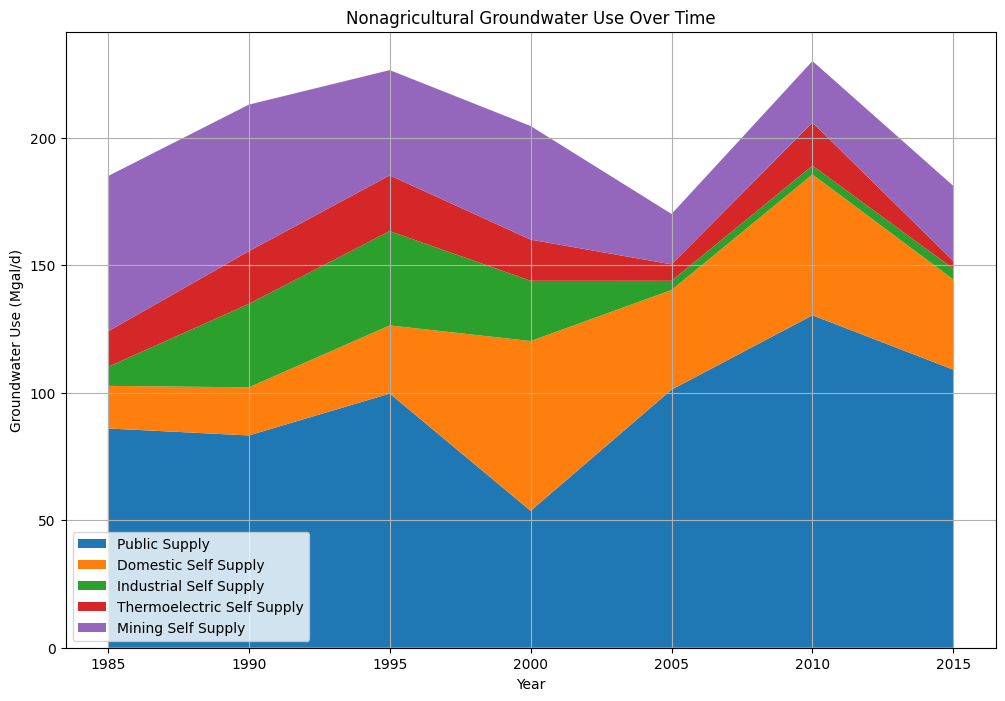

In [ ]:
# plot a stacked line chart as a function of ground_wateruse['year']

# Stacked line plot of groundwater use
plt.figure(figsize=(12, 8))
plt.stackplot(ground_wateruse['year'],
              ground_wateruse['Public_Supply'],
              ground_wateruse['Domestic_Self'],
              ground_wateruse['Industrial_Self'],
              ground_wateruse['Thermoelectric_Self'],
              ground_wateruse['Mining_Self'],
              labels=[ 'Public Supply', 'Domestic Self Supply', 'Industrial Self Supply', 'Thermoelectric Self Supply', 'Mining Self Supply'])
plt.xlabel('Year')
plt.ylabel('Groundwater Use (Mgal/d)')
plt.title('Nonagricultural Groundwater Use Over Time')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

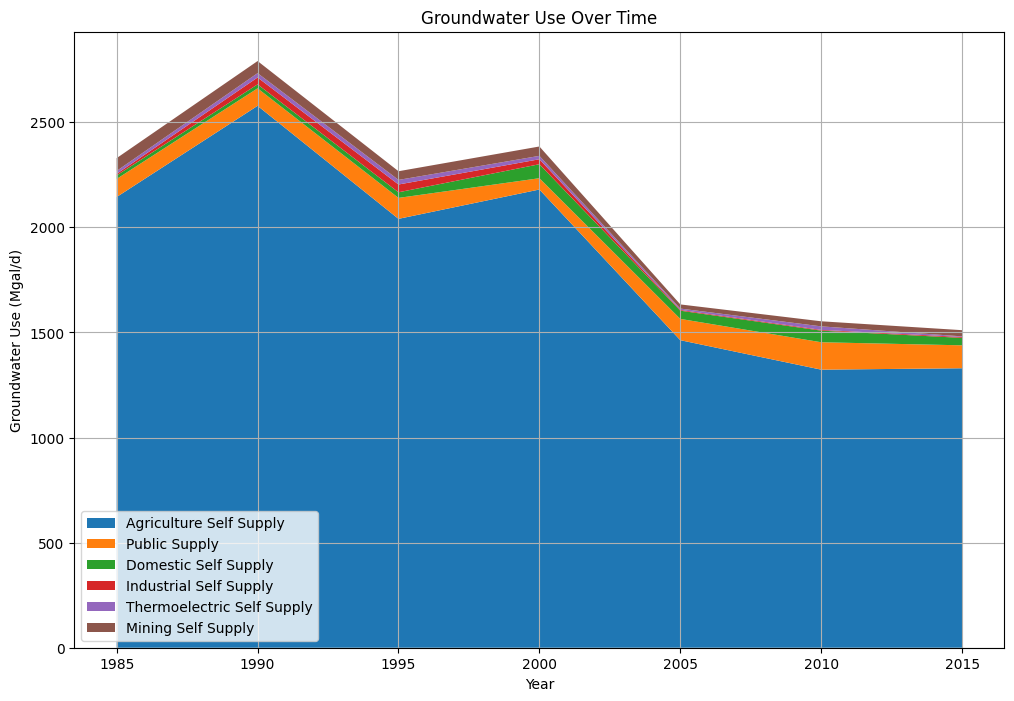

In [ ]:
# prompt: plot a stacked line chart as a function of ground_wateruse['year']

# Stacked line plot of groundwater use
plt.figure(figsize=(12, 8))
plt.stackplot(ground_wateruse['year'],
              ground_wateruse['Agriculture_Self'],
              ground_wateruse['Public_Supply'],
              ground_wateruse['Domestic_Self'],
              ground_wateruse['Industrial_Self'],
              ground_wateruse['Thermoelectric_Self'],
              ground_wateruse['Mining_Self'],
              labels=['Agriculture Self Supply', 'Public Supply', 'Domestic Self Supply', 'Industrial Self Supply', 'Thermoelectric Self Supply', 'Mining Self Supply'])
plt.xlabel('Year')
plt.ylabel('Groundwater Use (Mgal/d)')
plt.title('Groundwater Use Over Time')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

In [ ]:
# Create a list of columns with the substring 'surface'
cols_surfacewater = [col for col in water_use.columns if 'surface' in col]
print(cols_surfacewater)
#print length of cols_surfacewater
print(len(cols_surfacewater))

['Public Supply population served by surface water, in thousands', 'Public Supply self-supplied surface-water withdrawals, fresh, in Mgal/d', 'Public Supply self-supplied surface-water withdrawals, saline, in Mgal/d', 'Public Supply total self-supplied withdrawals, surface water, in Mgal/d', 'Domestic self-supplied surface-water withdrawals, fresh, in Mgal/d', 'Domestic self-supplied surface-water withdrawals, saline, in Mgal/d', 'Domestic total self-supplied withdrawals, surface water, in Mgal/d', 'Commercial self-supplied surface-water withdrawals, fresh, in Mgal/d', 'Commercial self-supplied surface-water withdrawals, saline, in Mgal/d', 'Commercial total self-supplied withdrawals, surface water, in Mgal/d', 'Industrial self-supplied surface-water withdrawals, fresh, in Mgal/d', 'Industrial self-supplied surface-water withdrawals, saline, in Mgal/d', 'Industrial total self-supplied withdrawals, surface water, in Mgal/d', 'Total Thermoelectric Power self-supplied surface-water withdr

In [ ]:
# create a new dataframe with only the columns in cols_surfacewater and 'year'
surface_wateruse = water_use[['year'] + cols_surfacewater].copy()
#keep only necessary columns
surface_wateruse=surface_wateruse[['year',
'Public Supply self-supplied surface-water withdrawals, fresh, in Mgal/d',
'Domestic self-supplied surface-water withdrawals, fresh, in Mgal/d',
'Industrial self-supplied surface-water withdrawals, fresh, in Mgal/d',
'Total Thermoelectric Power self-supplied surface-water withdrawals, fresh, in Mgal/d',
'Fossil-fuel Thermoelectric Power total self-supplied withdrawals, surface water, in Mgal/d',
'Nuclear Thermoelectric Power total self-supplied withdrawals, surface water, in Mgal/d',
'Mining total self-supplied withdrawals, surface water, in Mgal/d',
'Livestock self-supplied surface-water withdrawals, fresh, in Mgal/d',
'Livestock (Stock) self-supplied surface-water withdrawals, fresh, in Mgal/d',
'Irrigation, Total self-supplied surface-water withdrawals, fresh, in Mgal/d',
                   ]].copy()

# combine the thermoelectric columns
#convert electric to numeric
surface_wateruse['Total Thermoelectric Power self-supplied surface-water withdrawals, fresh, in Mgal/d'] = pd.to_numeric(surface_wateruse['Total Thermoelectric Power self-supplied surface-water withdrawals, fresh, in Mgal/d'], errors='coerce')
surface_wateruse['Nuclear Thermoelectric Power total self-supplied withdrawals, surface water, in Mgal/d'] = pd.to_numeric(surface_wateruse['Nuclear Thermoelectric Power total self-supplied withdrawals, surface water, in Mgal/d'], errors='coerce')
surface_wateruse['Fossil-fuel Thermoelectric Power total self-supplied withdrawals, surface water, in Mgal/d'] = pd.to_numeric(surface_wateruse['Fossil-fuel Thermoelectric Power total self-supplied withdrawals, surface water, in Mgal/d'], errors='coerce')
# create a new column for Thermoelectric_Self by combining the relevant columns,
surface_wateruse['Thermoelectric_Self'] = surface_wateruse['Fossil-fuel Thermoelectric Power total self-supplied withdrawals, surface water, in Mgal/d'].fillna(0) + surface_wateruse['Nuclear Thermoelectric Power total self-supplied withdrawals, surface water, in Mgal/d'].fillna(0)
# surface_wateruse['Thermoelectric_Self] = max of surface_wateruse['Thermoelectric_Self] and surface_wateruse['Total Thermoelectric Power self-supplied surface-water withdrawals, fresh, in Mgal/d']
surface_wateruse['Thermoelectric_Self'] = surface_wateruse[['Thermoelectric_Self', 'Total Thermoelectric Power self-supplied surface-water withdrawals, fresh, in Mgal/d']].max(axis=1)
#drop the unecessary columns
surface_wateruse  = surface_wateruse.drop(columns=['Total Thermoelectric Power self-supplied surface-water withdrawals, fresh, in Mgal/d', 'Nuclear Thermoelectric Power total self-supplied withdrawals, surface water, in Mgal/d', 'Fossil-fuel Thermoelectric Power total self-supplied withdrawals, surface water, in Mgal/d'])

# combine the agriculture columns
# convert livestock columns to numeric
surface_wateruse['Livestock self-supplied surface-water withdrawals, fresh, in Mgal/d'] = pd.to_numeric(surface_wateruse['Livestock self-supplied surface-water withdrawals, fresh, in Mgal/d'], errors='coerce')
surface_wateruse['Livestock (Stock) self-supplied surface-water withdrawals, fresh, in Mgal/d'] = pd.to_numeric(surface_wateruse['Livestock (Stock) self-supplied surface-water withdrawals, fresh, in Mgal/d'], errors='coerce')
#calculate the sum of livestock columns
surface_wateruse['Agriculture_Self'] = surface_wateruse['Irrigation, Total self-supplied surface-water withdrawals, fresh, in Mgal/d'] + surface_wateruse['Livestock self-supplied surface-water withdrawals, fresh, in Mgal/d'].fillna(0) + surface_wateruse['Livestock (Stock) self-supplied surface-water withdrawals, fresh, in Mgal/d'].fillna(0)
#drop livestock and irrigation columns
surface_wateruse.drop(columns=['Irrigation, Total self-supplied surface-water withdrawals, fresh, in Mgal/d','Livestock self-supplied surface-water withdrawals, fresh, in Mgal/d', 'Livestock (Stock) self-supplied surface-water withdrawals, fresh, in Mgal/d'], inplace=True)

#Rename necessary columns
surface_wateruse.rename(columns={
  'Public Supply self-supplied surface-water withdrawals, fresh, in Mgal/d': 'Public_Supply',
  'Domestic self-supplied surface-water withdrawals, fresh, in Mgal/d': 'Domestic_Self',
  'Industrial self-supplied surface-water withdrawals, fresh, in Mgal/d': 'Industrial_Self',
  'Mining total self-supplied withdrawals, surface water, in Mgal/d': 'Mining_Self'
  }, inplace=True)

# Calculate the sum of all columns in surface_wateruse, excluding 'year'
surface_wateruse['Total_Surfacewater_Use'] = surface_wateruse.drop(columns=['year']).sum(axis=1)
# Display the updated dataframe
print(surface_wateruse.columns)
print(surface_wateruse.dtypes)
display(surface_wateruse)

Index(['year', 'Public_Supply', 'Domestic_Self', 'Industrial_Self',
       'Mining_Self', 'Thermoelectric_Self', 'Agriculture_Self',
       'Total_Surfacewater_Use'],
      dtype='object')
year                        int64
Public_Supply             float64
Domestic_Self             float64
Industrial_Self           float64
Mining_Self               float64
Thermoelectric_Self       float64
Agriculture_Self          float64
Total_Surfacewater_Use    float64
dtype: object


,year,Public_Supply,Domestic_Self,Industrial_Self,Mining_Self,Thermoelectric_Self,Agriculture_Self,Total_Surfacewater_Use
0,1985,651.08,0.0,112.91,30.40,95.87,10330.17,11220.43
1,1990,566.99,0.0,84.93,26.34,93.62,9127.78,9899.66
2,1995,605.35,0.0,86.47,26.84,92.58,10739.45,11550.69
3,2000,845.72,0.0,96.40,19.59,122.06,9285.09,10368.86
4,2005,739.22,0.0,138.83,1.63,122.00,9813.58,10815.26
5,2010,690.39,0.0,126.78,3.91,60.01,8430.77,9311.86
6,2015,734.90,0.0,79.86,2.46,34.13,7703.35,8554.70


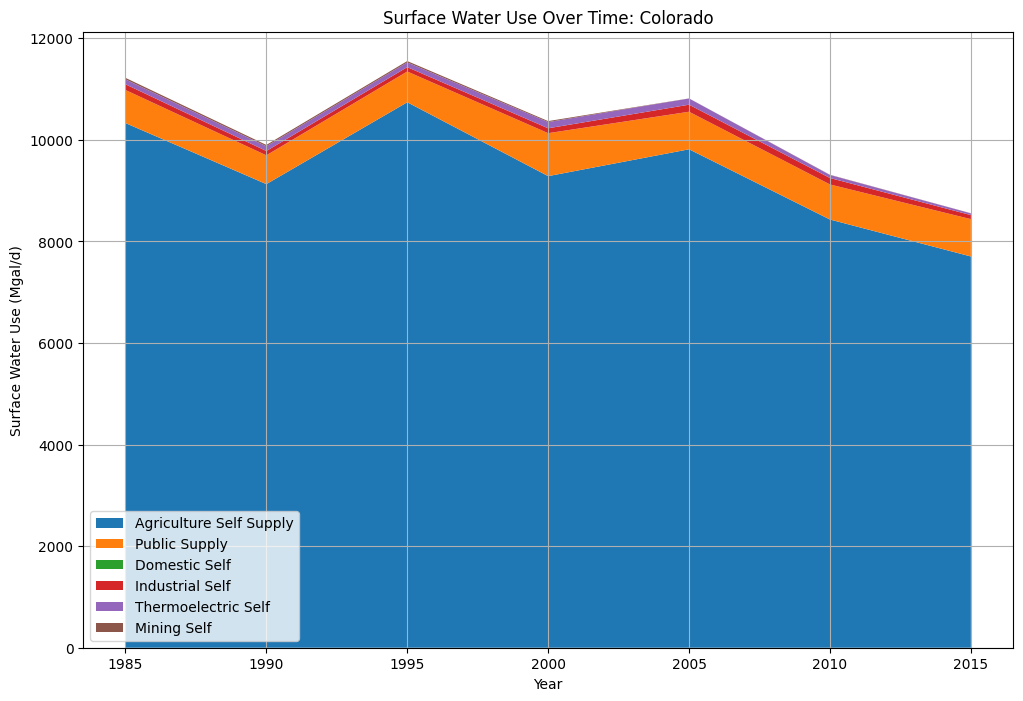

In [ ]:
# plot a stacked line chart as a function of surface_wateruse['year']
# Stacked line plot of surface water use
plt.figure(figsize=(12, 8))
plt.stackplot(surface_wateruse['year'],
              surface_wateruse['Agriculture_Self'],
              surface_wateruse['Public_Supply'],
              surface_wateruse['Domestic_Self'],
              surface_wateruse['Industrial_Self'],
              surface_wateruse['Thermoelectric_Self'],
              surface_wateruse['Mining_Self'],
              labels=['Agriculture Self Supply', 'Public Supply', 'Domestic Self', 'Industrial Self', 'Thermoelectric Self', 'Mining Self', 'Livestock Self', 'Irrigation Self'])
plt.xlabel('Year')
plt.ylabel('Surface Water Use (Mgal/d)')
plt.title('Surface Water Use Over Time: Colorado')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

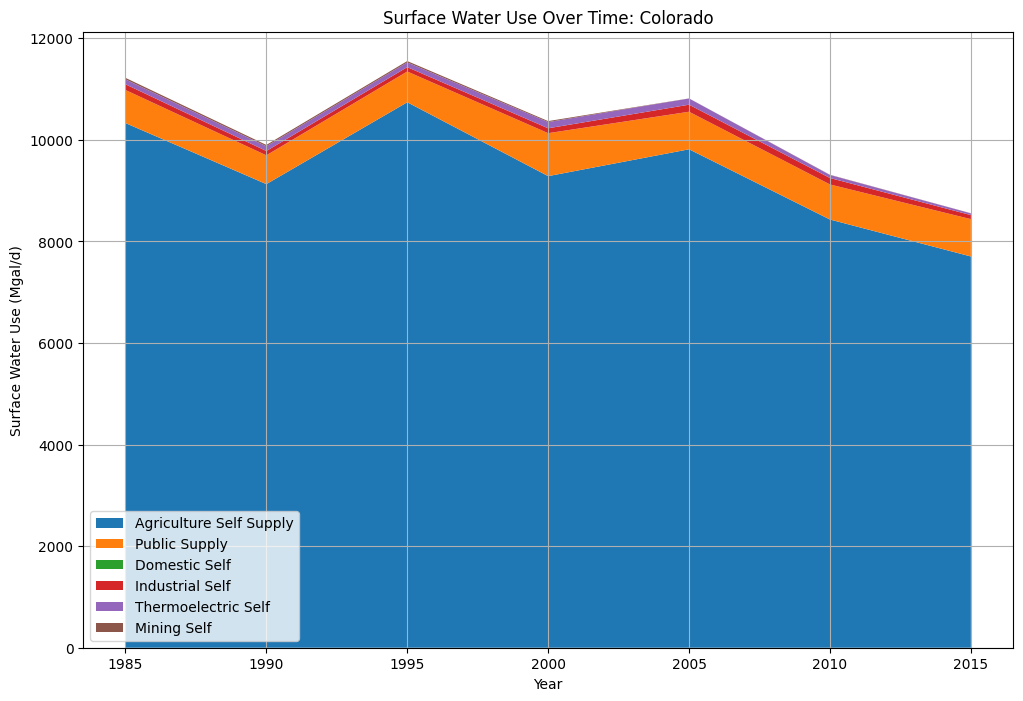

In [ ]:
#  plot a stacked line chart as a function of surface_wateruse['year']

# Stacked line plot of surface water use
plt.figure(figsize=(12, 8))
plt.stackplot(surface_wateruse['year'],
              surface_wateruse['Agriculture_Self'],
              surface_wateruse['Public_Supply'],
              surface_wateruse['Domestic_Self'],
              surface_wateruse['Industrial_Self'],
              surface_wateruse['Thermoelectric_Self'],
              surface_wateruse['Mining_Self'],
              labels=['Agriculture Self Supply', 'Public Supply', 'Domestic Self', 'Industrial Self', 'Thermoelectric Self', 'Mining Self', 'Livestock Self', 'Irrigation Self'])
plt.xlabel('Year')
plt.ylabel('Surface Water Use (Mgal/d)')
plt.title('Surface Water Use Over Time: Colorado')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

In [ ]:
# create a new dataframe all_wateruse calculated by the sums of surface_wateruse and ground_wateruse,
# Merge the two dataframes on 'year'
all_wateruse = pd.merge(ground_wateruse, surface_wateruse, on='year', suffixes=('_ground', '_surface'))

# Initialize a dictionary to store the summed columns
summed_data = {'year': all_wateruse['year']}

# Iterate through the columns present in both dataframes (excluding 'year')
# and sum the corresponding columns from groundwater and surface_wateruse
for col in ground_wateruse.columns:
    if col != 'year' and col in surface_wateruse.columns:
        summed_data[col] = all_wateruse[col + '_ground'] + all_wateruse[col + '_surface']

# Create the new dataframe
all_wateruse = pd.DataFrame(summed_data)

# Calculate the total sum across all use types for the new dataframe
all_wateruse['Total_All_Water_Use'] = all_wateruse.drop(columns=['year']).sum(axis=1)
all_wateruse['Total_Groundwater_Use'] = ground_wateruse['Total_Groundwater_Use']
all_wateruse['Total_Surfacewater_Use'] = surface_wateruse['Total_Surfacewater_Use']

display(all_wateruse)

,year,Public_Supply,Domestic_Self,Industrial_Self,Thermoelectric_Self,Mining_Self,Agriculture_Self,Total_All_Water_Use,Total_Groundwater_Use,Total_Surfacewater_Use
0,1985,737.08,16.70,120.35,109.78,91.32,12474.44,13549.67,2329.24,11220.43
1,1990,650.25,18.86,117.67,114.29,83.82,11705.71,12690.60,2790.94,9899.66
2,1995,705.03,26.73,123.48,114.42,68.13,12779.71,13817.50,2266.81,11550.69
3,2000,899.41,66.60,120.03,138.20,64.15,11464.99,12753.38,2384.52,10368.86
4,2005,840.44,39.08,142.44,128.46,21.39,11276.63,12448.44,1633.18,10815.26
5,2010,820.78,55.24,130.23,76.90,28.04,9753.60,10864.79,1552.93,9311.86
6,2015,843.95,35.37,84.08,37.16,31.91,9032.90,10065.37,1510.67,8554.70


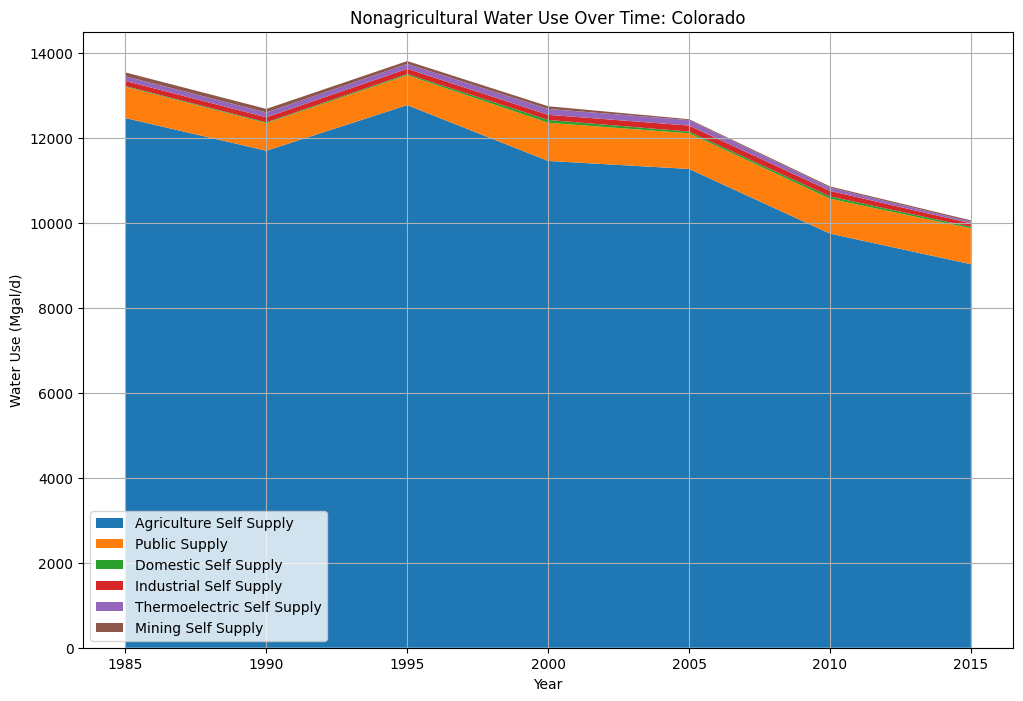

In [ ]:
# plot a stacked line chart as a function of all_wateruse['year']
# Stacked line plot of all water use
plt.figure(figsize=(12, 8))
plt.stackplot(all_wateruse['year'],
              all_wateruse['Agriculture_Self'],
              all_wateruse['Public_Supply'],
              all_wateruse['Domestic_Self'],
              all_wateruse['Industrial_Self'],
              all_wateruse['Thermoelectric_Self'],
              all_wateruse['Mining_Self'],
              labels=['Agriculture Self Supply', 'Public Supply', 'Domestic Self Supply', 'Industrial Self Supply', 'Thermoelectric Self Supply', 'Mining Self Supply'])
plt.xlabel('Year')
plt.ylabel('Water Use (Mgal/d)')
plt.title('Nonagricultural Water Use Over Time: Colorado')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

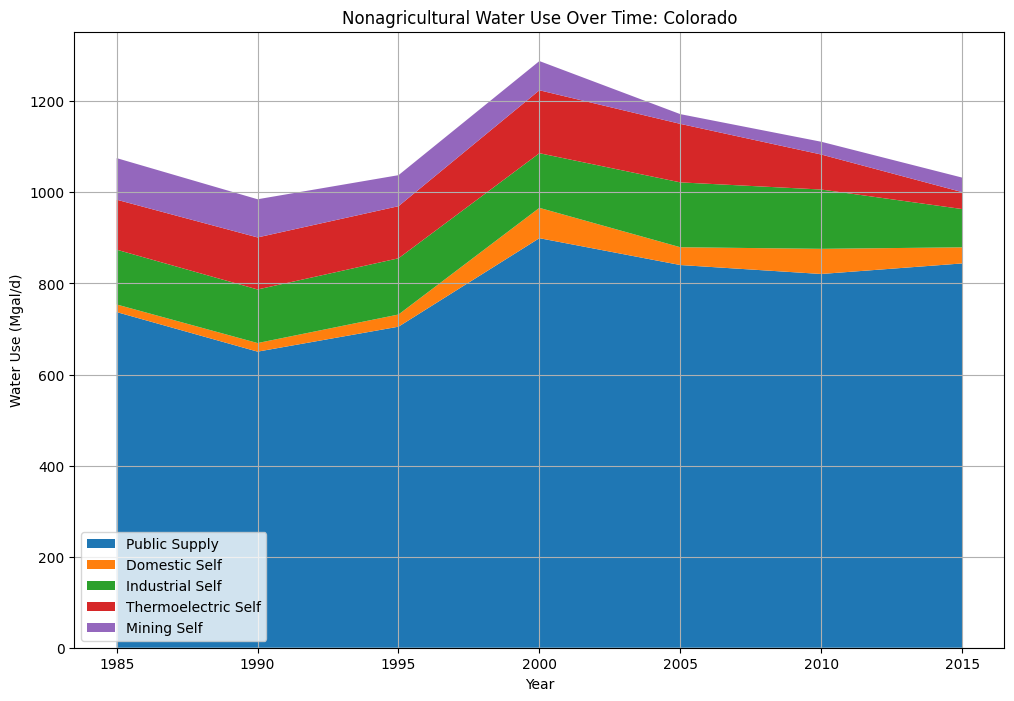

In [ ]:
# plot a stacked line chart as a function of all_wateruse['year']
# Stacked line plot of all water use
plt.figure(figsize=(12, 8))
plt.stackplot(all_wateruse['year'],
              all_wateruse['Public_Supply'],
              all_wateruse['Domestic_Self'],
              all_wateruse['Industrial_Self'],
              all_wateruse['Thermoelectric_Self'],
              all_wateruse['Mining_Self'],
              labels=['Public Supply', 'Domestic Self', 'Industrial Self', 'Thermoelectric Self', 'Mining Self', 'Livestock Self', 'Irrigation Self'])
plt.xlabel('Year')
plt.ylabel('Water Use (Mgal/d)')
plt.title('Nonagricultural Water Use Over Time: Colorado')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

In [1]:
# create a stacked line plot of Total_Groundwater_Use and Total_Surfacewater_Use as a function of years
plt.figure(figsize=(12, 8))
plt.stackplot(all_wateruse['year'],
              all_wateruse['Total_Groundwater_Use'],
              all_wateruse['Total_Surfacewater_Use'],
              labels=['Total Groundwater Use', 'Total Surfacewater Use'])
plt.xlabel('Year')
plt.ylabel('Water Use (Mgal/d)')
plt.title('Total Groundwater and Surfacewater Use Over Time')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

In [ ]:
print(all_wateruse.columns)

Index(['year', 'Public_Supply', 'Domestic_Self', 'Industrial_Self',
       'Thermoelectric_Self', 'Mining_Self', 'Agriculture_Self',
       'Total_All_Water_Use', 'Total_Groundwater_Use',
       'Total_Surfacewater_Use'],
      dtype='object')


In [ ]:
# create an interactive plot of water withdrawals over time by sources groundwater and surfacewater
!pip install plotly
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# Define the columns to plot and their desired labels
columns_to_plot = {
    'Total_Surfacewater_Use': 'Surfacewater Withdrawals',
    'Total_Groundwater_Use': 'Groundwater Withdrawals',
}

# Define the color map
color_map = {'Surface_Use':'teal','Ground_Use':'brown'}


# Select only the columns that exist in all_wateruse and are in columns_to_plot
cols_to_melt = [col for col in columns_to_plot.keys() if col in all_wateruse.columns]

# Melt the DataFrame
all_wateruse_melted = all_wateruse.melt(id_vars=['year'],
                                  value_vars=cols_to_melt,
                                  var_name='Category',
                                  value_name='Water Use (Mgal/d)')

# Create a mapping for more descriptive labels using the columns_to_plot dictionary
label_map = columns_to_plot

# Replace the category names with the more descriptive labels
all_wateruse_melted['Category'] = all_wateruse_melted['Category'].map(label_map)

# Calculate peak value for each category and sort
peak_values = all_wateruse_melted.groupby('Category')['Water Use (Mgal/d)'].max().sort_values(ascending=False)
sorted_categories = peak_values.index.tolist()

# Create the interactive plot using Plotly Express
fig = px.line(all_wateruse_melted,
              x='year',
              y='Water Use (Mgal/d)',
              color='Category',
              title='Water Withdrawal Source Over Time: Colorado',
              labels={'year':'Year'},
              category_orders={'Category': sorted_categories}, # Set the order of categories
              color_discrete_map=color_map) # Set the colors using the color map

fig.update_layout(
    hovermode="x unified", # Unify hover for better comparison
    title_font_size=30,  # Increase title font size
    legend_title_font_size=20, # Increase legend title font size
    xaxis=dict(title_font_size=20, tickfont=dict(size=18)), # Increase x-axis label font size
    yaxis=dict(title_font_size=20, tickfont=dict(size=18)),  # Increase y-axis label and tick font size
    legend=dict(font=dict(size=18)) # Increase legend font size
)
fig.show()
#export the figure as an html
fig.write_html("water_source_colorado.html")

In [ ]:
# create an interactive plot of water withdrawals over time by uses
!pip install plotly
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# Define the columns to plot and their desired labels
columns_to_plot = {
    'Public_Supply': 'Public Supply',
    'Domestic_Self': 'Domestic (self-supplied)',
    'Industrial_Self': 'Industrial (self-supplied)',
    'Thermoelectric_Self': 'Thermoelectric (self-supplied)',
    'Mining_Self': 'Mining (self-supplied)',
    'Agriculture_Self': 'Agriculture (self-supplied)'
}

# Define the color map
color_map = {
    'Public Supply': 'blue',
    'Domestic (self-supplied)': 'red',
    'Industrial (self-supplied)': 'green',
    'Thermoelectric (self-supplied)': 'purple',
    'Mining (self-supplied)': 'orange',
    'Agriculture (self-supplied)': 'brown'
}


# Select only the columns that exist in all_wateruse and are in columns_to_plot
cols_to_melt = [col for col in columns_to_plot.keys() if col in all_wateruse.columns]

# Melt the DataFrame
all_wateruse_melted = all_wateruse.melt(id_vars=['year'],
                                  value_vars=cols_to_melt,
                                  var_name='Category',
                                  value_name='Water Use (Mgal/d)')

# Create a mapping for more descriptive labels using the columns_to_plot dictionary
label_map = columns_to_plot

# Replace the category names with the more descriptive labels
all_wateruse_melted['Category'] = all_wateruse_melted['Category'].map(label_map)

# Calculate peak value for each category and sort
peak_values = all_wateruse_melted.groupby('Category')['Water Use (Mgal/d)'].max().sort_values(ascending=False)
sorted_categories = peak_values.index.tolist()

# Create the interactive plot using Plotly Express
fig = px.line(all_wateruse_melted,
              x='year',
              y='Water Use (Mgal/d)',
              color='Category',
              title='Water Withdrawal Use Over Time: Colorado',
              labels={'year':'Year'},
              category_orders={'Category': sorted_categories}, # Set the order of categories
              color_discrete_map=color_map) # Set the colors using the color map

fig.update_layout(
    hovermode="x unified", # Unify hover for better comparison
    title_font_size=30,  # Increase title font size
    legend_title_font_size=20, # Increase legend title font size
    xaxis=dict(title_font_size=20, tickfont=dict(size=18)), # Increase x-axis label font size
    yaxis=dict(title_font_size=20, tickfont=dict(size=18)),  # Increase y-axis label and tick font size)
    legend=dict(font=dict(size=18)) # Increase legend font size
)
fig.show()
fig.write_html("water_uses_colorado.html")